# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# Import chla data from Point B for 2023

In [2]:
chla_2023 = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Point_B/Point_B_chla_2023.csv', delimiter = ';')
chla_2023['DATE'] = pd.to_datetime(chla_2023['DATE'], format='%d/%m/%Y')
chla_2023 = chla_2023[chla_2023['CHLA_µg_l'] < 900]
chla_2023['CHLA_mg_m3'] = chla_2023['CHLA_µg_l']
chla_2023.head(3)

,DATE,Depth,Lat,Lon,CHLA_µg_l,CHLA_mg_m3
0,2023-01-03,1.0,43.6833,7.31667,0.42,0.42
1,2023-01-10,1.0,43.6833,7.31667,0.27,0.27
2,2023-01-17,1.0,43.6833,7.31667,0.62,0.62
3,2023-01-25,1.0,43.6833,7.31667,0.65,0.65
4,2023-01-31,1.0,43.6833,7.31667,0.56,0.56
5,2023-02-07,1.0,43.6833,7.31667,0.55,0.55
6,2023-02-14,1.0,43.6833,7.31667,0.41,0.41
7,2023-02-21,1.0,43.6833,7.31667,0.63,0.63
8,2023-02-28,1.0,43.6833,7.31667,0.37,0.37
9,2023-03-07,1.0,43.6833,7.31667,0.54,0.54


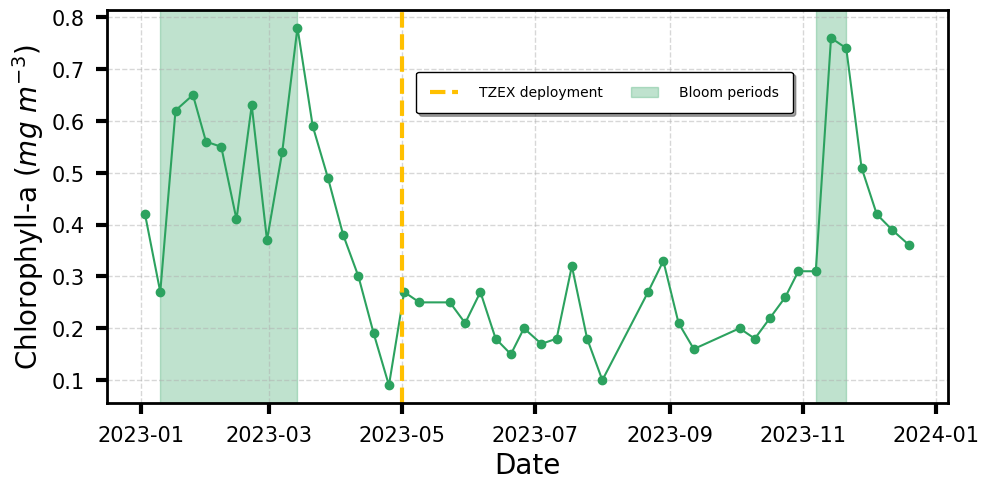

In [3]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(chla_2023['DATE'], chla_2023['CHLA_mg_m3'], linestyle='-', marker='o', color='#2ca25f')

# Add vertical line
vline_date = pd.to_datetime('01/05/2023', format='%d/%m/%Y')
ax.axvline(x=vline_date, color='#FFC000', linestyle='--', label='TZEX deployment', alpha =1, linewidth = 3)

# Add shaded bloom period
start_bloom_spring = pd.to_datetime('10/01/2023', format='%d/%m/%Y')
end_bloom_spring = pd.to_datetime('14/03/2023', format='%d/%m/%Y')
ax.axvspan(start_bloom_spring, end_bloom_spring, color='#2ca25f', alpha=0.3, label='Bloom periods')

start_bloom_aut = pd.to_datetime('07/11/2023', format='%d/%m/%Y')
end_bloom_aut = pd.to_datetime('21/11/2023', format='%d/%m/%Y')
ax.axvspan(start_bloom_aut, end_bloom_aut, color='#2ca25f', alpha=0.3, label='')

# Labels
size = 20
pad = 8

ax.set_xlabel('Date', fontsize=size)
ax.set_ylabel('Chlorophyll-a ($mg$ $m^{-3}$)', fontsize=size)

# Tick parameters
l = 8
w = 3
ax.tick_params(axis='y', labelsize=size-5, pad=pad, length=l, width=w)
ax.tick_params(axis='x', labelsize=size-5, pad=pad, length=l, width=w)

ax.grid(True, linestyle='--', linewidth=1, alpha=0.5)

ax.legend(bbox_to_anchor=(0.36, 0.86),
          labelspacing=1.5, fontsize=10,
          markerscale=0.5, handletextpad=1.5, borderpad=1,
          edgecolor='black', frameon=True, framealpha=1,
          fancybox=True, shadow=True, ncol=2) # bbox_to_anchor=(0.6, 0.05)

plt.xticks(rotation=0)

# Set spine width
for spine in ax.spines.values():
    spine.set_linewidth(2)
    
plt.tight_layout()
plt.savefig('/home/aaccardo/these_alex/Papers/Rising_stars/Figure_S2/Figure_S2.png', dpi = 300)
plt.show()